# **III. Model**

## **III.1. Volume cycles**
We plot daily, weekly and monthly average volume to check for trends. Timestamps are in UTC. 

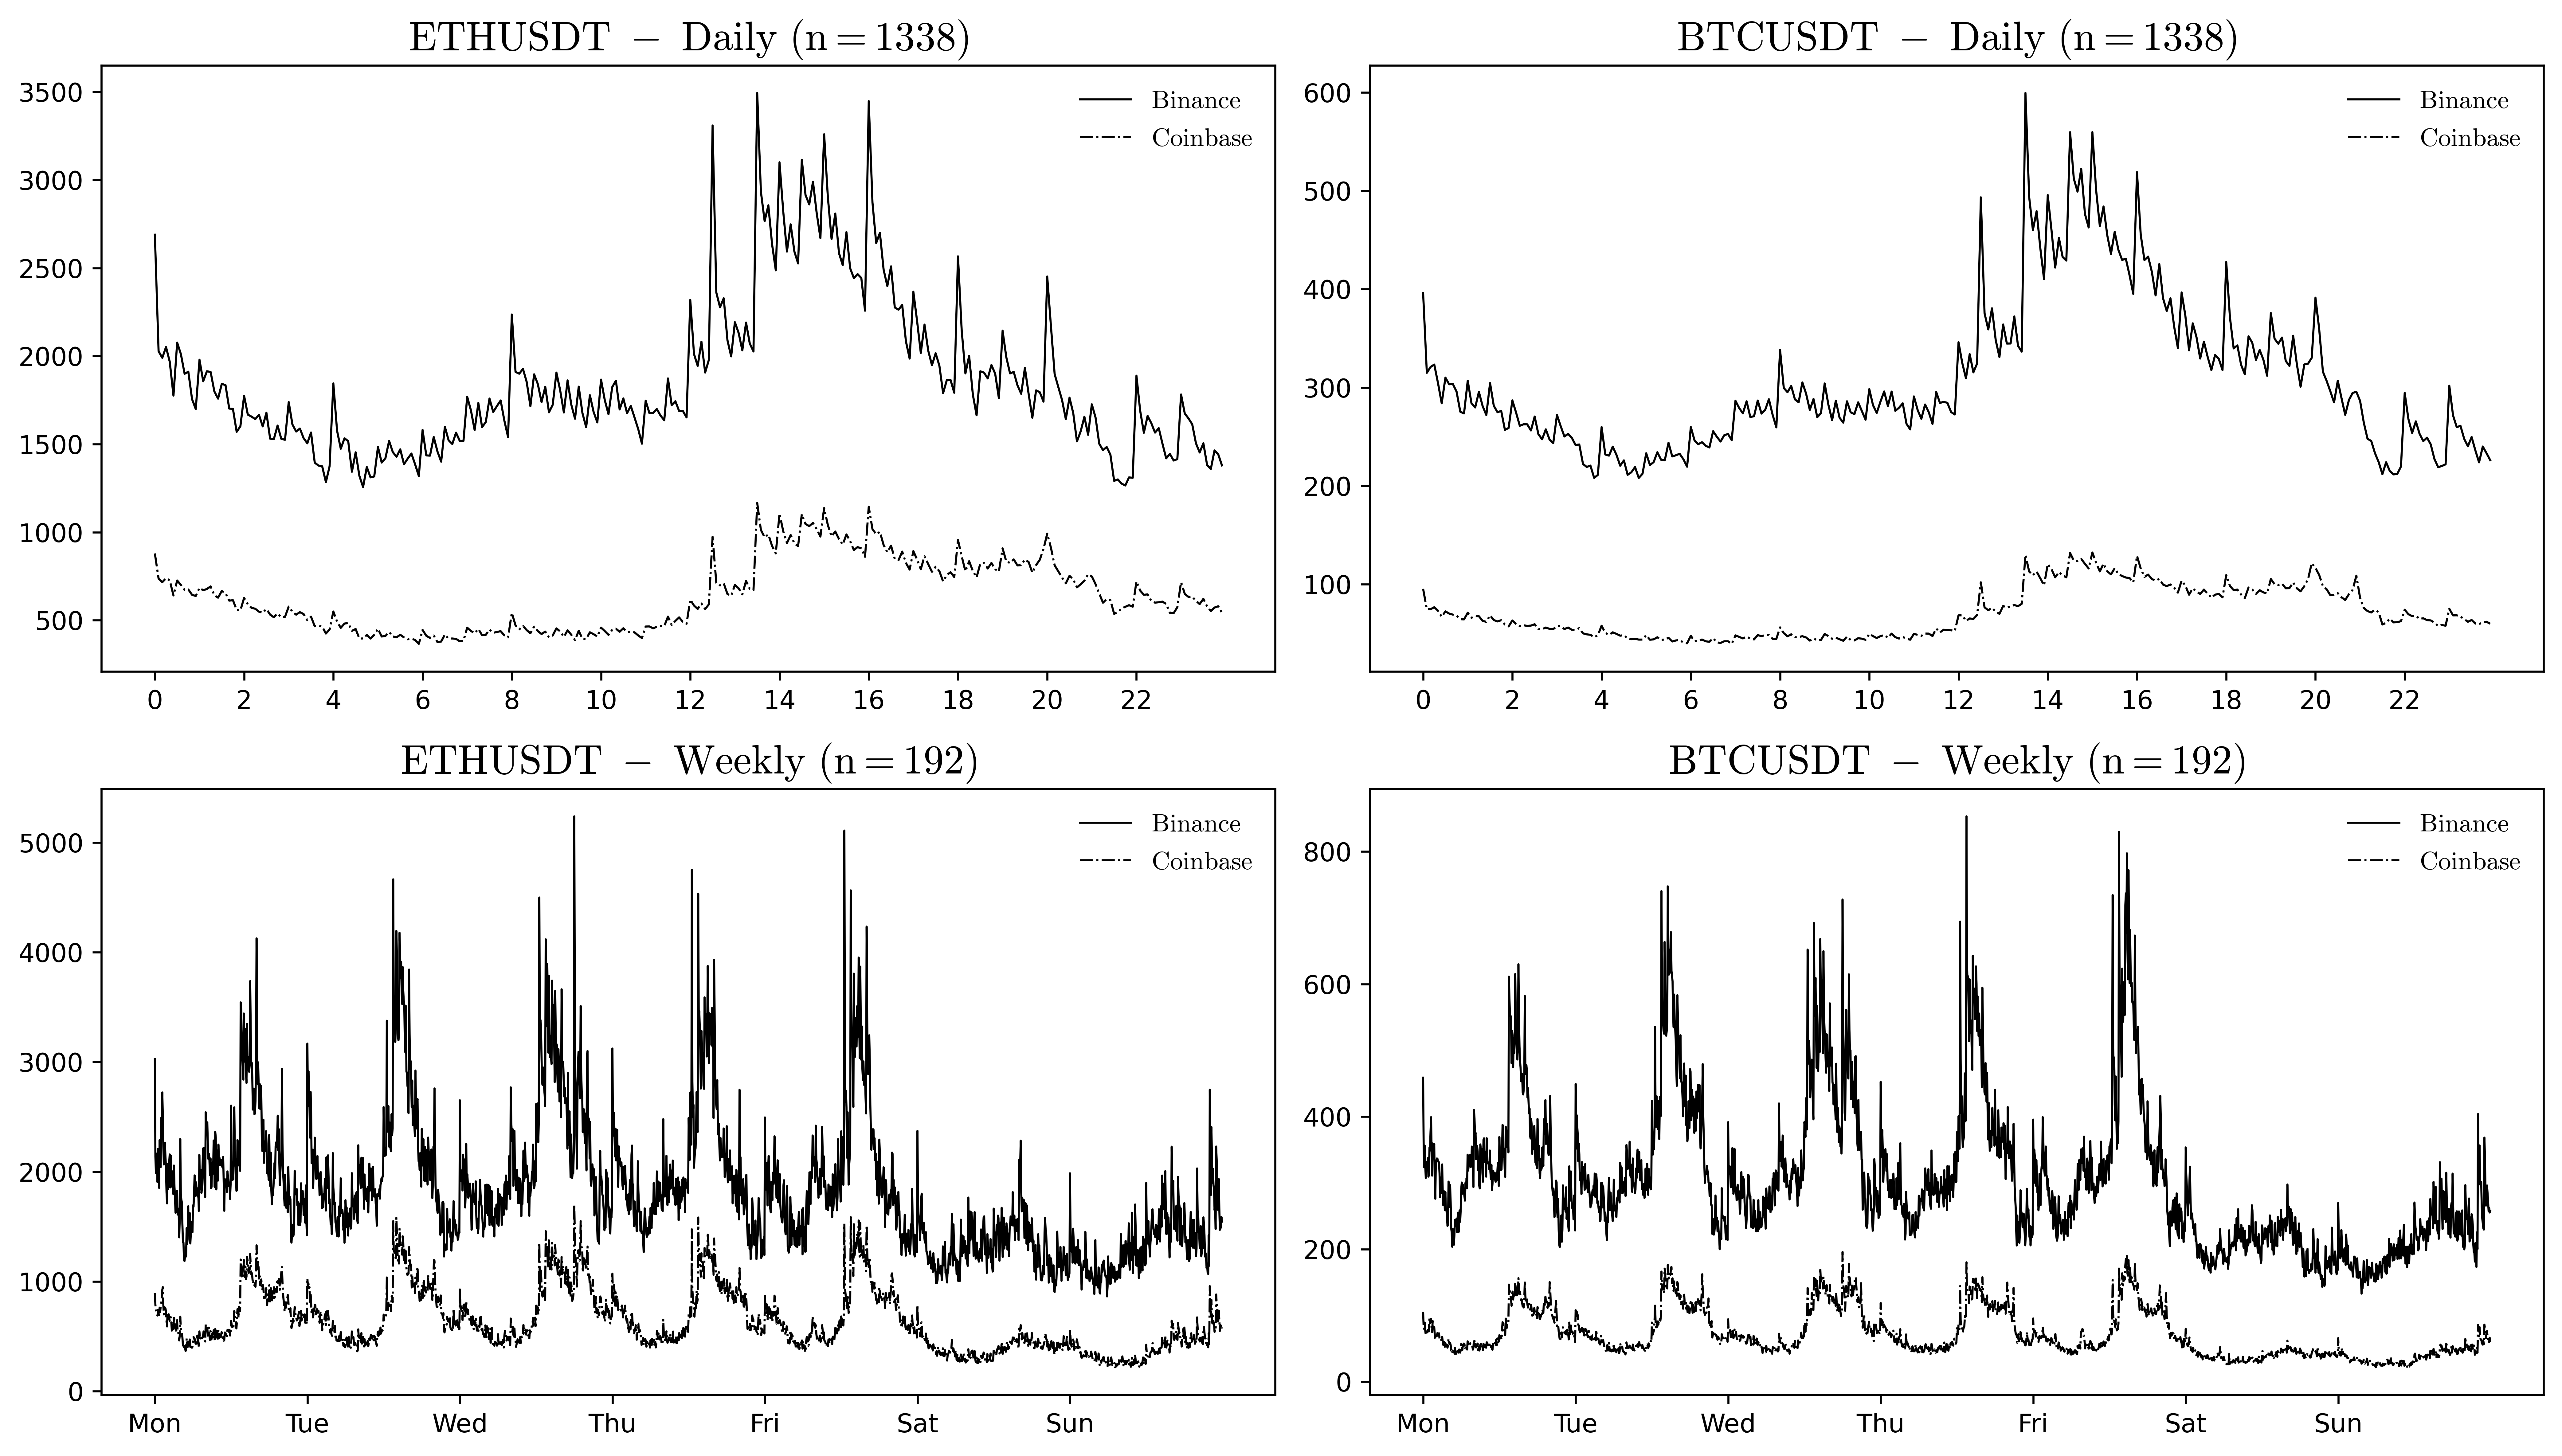

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import duckdb

con = duckdb.connect('/Users/eyquem/Desktop/CRED/code/data.db')

# Binance data
def get_5m_df(symbol):
    query = f"""
        SELECT CAST(timestamp AS BIGINT) AS timestamp, CAST(volume AS FLOAT) AS volume
        FROM ohlcv_5m
        WHERE symbol = '{symbol}'
        ORDER BY timestamp
    """
    df = con.execute(query).df()
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("datetime")
    df = df[(df.index >= "2021-05-04") & (df.index <= "2024-12-31")]
    return df

# Coinbase data
def get_5m_df_cb(symbol):
    table_name = f"CB_{symbol.replace('-', '')}_1m"
    query = f"""
        SELECT start, TRY_CAST(volume AS FLOAT) AS volume
        FROM {table_name}
        ORDER BY start
    """
    df = con.execute(query).df()
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df = df.dropna(subset=["start"])
    df["datetime"] = pd.to_datetime(df["start"].astype("int64"), unit="s")
    df = df.set_index("datetime")
    df = df[(df.index >= "2021-05-04") & (df.index <= "2024-12-31")]
    df5m = df["volume"].resample("5min").sum().to_frame()
    return df5m

plt.rcParams["mathtext.fontset"] = "cm"
fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=600)

symbols_cb = {"ETHUSDT": "ETH-USD", "BTCUSDT": "BTC-USD"}

for col_idx, symbol in enumerate(["ETHUSDT", "BTCUSDT"]):
    df5m = get_5m_df(symbol)
    df5m_cb = get_5m_df_cb(symbols_cb[symbol])

    # daily: time-of-day in hours, 5m bins
    hour_frac = df5m.index.hour + df5m.index.minute / 60
    daily = df5m.groupby(hour_frac)["volume"].mean()
    n_days = df5m.index.normalize().nunique()

    hour_frac_cb = df5m_cb.index.hour + df5m_cb.index.minute / 60
    daily_cb = df5m_cb.groupby(hour_frac_cb)["volume"].mean()

    # weekly: time-of-week in hours, 5m bins
    week_frac = df5m.index.dayofweek * 24 + df5m.index.hour + df5m.index.minute / 60
    weekly = df5m.groupby(week_frac)["volume"].mean()
    n_weeks = df5m.index.to_period("W").nunique()

    week_frac_cb = df5m_cb.index.dayofweek * 24 + df5m_cb.index.hour + df5m_cb.index.minute / 60
    weekly_cb = df5m_cb.groupby(week_frac_cb)["volume"].mean()

    # plot
    axes[0, col_idx].plot(daily.index, daily.values, color="black", linewidth=0.8, label=r"$\mathrm{Binance}$")
    axes[0, col_idx].plot(daily_cb.index, daily_cb.values, color="black", linewidth=0.8, linestyle="-.", label=r"$\mathrm{Coinbase}$")
    axes[0, col_idx].set_xticks(range(0, 24, 2))
    axes[0, col_idx].set_title(rf"$\mathrm{{{symbol}\ -\ Daily\ (n={n_days})}}$", fontsize=16)
    axes[0, col_idx].legend(frameon=False)

    axes[1, col_idx].plot(weekly.index, weekly.values, color="black", linewidth=0.8, label=r"$\mathrm{Binance}$")
    axes[1, col_idx].plot(weekly_cb.index, weekly_cb.values, color="black", linewidth=0.8, linestyle="-.", label=r"$\mathrm{Coinbase}$")
    axes[1, col_idx].set_xticks(range(0, 7 * 24, 24))
    axes[1, col_idx].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    axes[1, col_idx].set_title(rf"$\mathrm{{{symbol}\ -\ Weekly\ (n={n_weeks})}}$", fontsize=16)
    axes[1, col_idx].legend(frameon=False)

plt.tight_layout()
plt.show()

Taking into account the weekly trends we notice earlier, we follow the traditional 1, 5 and 20 days over 1-7-30 for our HAR model.

#### **III.5.2.1. In-sample fit: Binance & Coinbase**

Our target is $RV_{t+1}$.

Following Haugom et al. (2014), we define realized volatility over different time-horizon as the average of daily quantities: $RV_t^{w}=\frac{1}{x}(RV_t^{(d)}+RV_{t-1d}^{(d)}+...+RV_{t-x-1d}^{(d)}$.

We experiment on both ETHUSDT and BTCUSDT pairs, over the entire sample period and over each subperiod.

For each pair and period, we experiment with different models: RV (1, 5, 20) + every addition (volume, cross_vol, jt, amihud, Ramihud, Kyle, dummy) to then create additive models.

- We also experiment using BV instead of RV. 
- and over periods



On avait expérimenté avec S&P: rien de bien. Choisir RV ou BV, choisir la période, choisir le modèle. Puis forecast.



In [3]:
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
import numpy as np

# loading data
metrics_df = con.execute("SELECT * FROM metrics WHERE interval = '5m'").df()
metrics_df["date"] = pd.to_datetime(metrics_df["date"])

ohlcv_df = con.execute("SELECT * FROM ohlcv_5m").df()
ohlcv_df["datetime"] = pd.to_datetime(ohlcv_df["timestamp"], unit="ms")
ohlcv_df["date"] = ohlcv_df["datetime"].dt.floor("D")
volume_daily = ohlcv_df.groupby(["symbol", "date"])["volume"].sum().reset_index()

metrics_df = pd.merge(metrics_df, volume_daily, on=["symbol", "date"], how="left")

symbols = ["ETHUSDT", "BTCUSDT"]
dfs = {}
for symbol in symbols:
    sub = metrics_df[metrics_df["symbol"] == symbol].set_index("date").sort_index()
    sub["jt"] = np.maximum(sub["rv"] - sub["bv"], 0)
    dfs[(symbol, "1D")] = sub


# config
periods = {
    "full": ("2021-05-04", "2024-12-31"),
    "period1": ("2021-05-04", "2022-06-13"),
    "period2": ("2022-06-13", "2024-01-10"),
    "period3": ("2024-01-10", "2024-12-31"),
}

other_symbol = {"BTCUSDT": "ETHUSDT", "ETHUSDT": "BTCUSDT"}
all_performance_data = []


# Model
for symbol in symbols:
    df = dfs[(symbol, "1D")]
    df_other = dfs[(other_symbol[symbol], "1D")]
    log_volume = np.log(df["volume"]) # Log volume following Tseng et al.

    for measure in ["rv", "bv"]: # we explore both volatility measures
        cross_vol = df_other[measure].reindex(df.index)

        # Building features
        for lag_name, (l1, l2, l3) in [("1_5_20", (1, 5, 20))]:
            data = pd.DataFrame(index=df.index)
            data[measure] = df[measure]

            # HAR volatility components
            data[f"{measure}_{l1}"] = df[measure].shift(1) 
            data[f"{measure}_{l2}"] = df[measure].rolling(l2).mean().shift(1)
            data[f"{measure}_{l3}"] = df[measure].rolling(l3).mean().shift(1)

            # Volume horizons
            data[f"vol_{l1}"] = log_volume.shift(1)
            data[f"vol_{l2}"] = log_volume.rolling(l2).mean().shift(1)
            data[f"vol_{l3}"] = log_volume.rolling(l3).mean().shift(1)

            # Kyle's lambda horizons
            data[f"kyle_{l1}"] = df["kyle_lambda"].shift(1)
            data[f"kyle_{l2}"] = df["kyle_lambda"].rolling(l2).mean().shift(1)
            data[f"kyle_{l3}"] = df["kyle_lambda"].rolling(l3).mean().shift(1)

            # Amihud horizons
            data[f"amihud_{l1}"] = df["amihud"].shift(1)
            data[f"amihud_{l2}"] = df["amihud"].rolling(l2).mean().shift(1)
            data[f"amihud_{l3}"] = df["amihud"].rolling(l3).mean().shift(1)

            # Ramihud horizons
            data[f"Ramihud_{l1}"] = df["Ramihud"].shift(1)
            data[f"Ramihud_{l2}"] = df["Ramihud"].rolling(l2).mean().shift(1)
            data[f"Ramihud_{l3}"] = df["Ramihud"].rolling(l3).mean().shift(1)

            # Cross-volatility
            data[f"cross_vol"] = cross_vol.shift(1)

            # Jump component [max(RV-BV)]
            data["jt"] = df["jt"].shift(1)

            # Fee dummy (1 = no fees, 0 = fees)
            data["no_fee_dummy"] = ((df.index >= "2022-07-08") & (df.index < "2023-03-22")).astype(int)

            #data["target"] = df[measure].shift(-1)
            #data["target"] = df["bv"].shift(-1) # we do not use BV as our target
            data["target"] = df["rv"].shift(-1) # We use RV

            base = [f"{measure}_{l1}", f"{measure}_{l2}", f"{measure}_{l3}"]

            # Individual coefficients
            individual_variants = {
                "base": base,
                "+volume": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}"],
                "+cross_vol": base + [f"cross_vol"],
                "+jt": base + ["jt"],
                "+amihud": base + [f"amihud_{l1}", f"amihud_{l2}", f"amihud_{l3}"],
                "+Ramihud": base + [f"Ramihud_{l1}", f"Ramihud_{l2}", f"Ramihud_{l3}"],
                "+kyle": base + [f"kyle_{l1}", f"kyle_{l2}", f"kyle_{l3}"],
                "+dummy": base + ["no_fee_dummy"],
            }

            # Additive models
            additive_variants = {
                "base": base,
                "+volume": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}"],
                "+volume+kyle": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}", f"kyle_{l1}", f"kyle_{l2}", f"kyle_{l3}"],
                "+volume+kyle+jt": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}", f"kyle_{l1}", f"kyle_{l2}", f"kyle_{l3}", "jt"],
                "+volume+kyle+jt+cross_vol": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}", f"kyle_{l1}", f"kyle_{l2}", f"kyle_{l3}", "jt", f"cross_vol"],
                "+volume+kyle+jt+cross_vol+dummy": base + [f"vol_{l1}", f"vol_{l2}", f"vol_{l3}", f"kyle_{l1}", f"kyle_{l2}", f"kyle_{l3}", "jt", f"cross_vol", "no_fee_dummy"],
            }
            
            model_variants = {**individual_variants, **additive_variants}

            # Fitting the model on the global period
            for period_name, (start, end) in periods.items():
                period_end = pd.Timestamp(end)
                
                period_data = data[(data.index >= start) & (data.index <= period_end)].replace([np.inf, -np.inf], np.nan)

                models_individual = {}
                models_additive = {}
                metrics_data = []
                mse_base, r2_base = None, None

                for variant_name, regressors in model_variants.items():
                    cols = regressors + ["target"]
                    subset = period_data[cols].dropna()
                    valid_idx = subset.index

                    X = sm.add_constant(subset[regressors])
                    y = subset["target"]
                    model = sm.OLS(y, X).fit()

                    pred = model.predict(X)
                    mse = np.sqrt(np.mean((y - pred) ** 2))
                    r2 = model.rsquared_adj # We use adjusted r-squared

                    all_performance_data.append({"Symbol": symbol, "Measure": measure, "Lag": lag_name, "Period": period_name, "Model": variant_name, "MSE": mse, "R2": r2, "AIC": model.aic, "BIC": model.bic})
                    if variant_name in individual_variants:
                        models_individual[variant_name] = model
                    if variant_name in additive_variants:
                        models_additive[variant_name] = model

                # Printing coefficient tables only for final models
                if measure == "rv" and lag_name == "1_5_20":
                    print(f"\n{symbol} - {measure} - {lag_name} - {period_name} - Individual (n = {len(valid_idx)})")
                    print(summary_col(list(models_individual.values()), model_names=list(models_individual.keys()), stars=True, info_dict={"AIC": lambda x: f"{x.aic:.2f}", "BIC": lambda x: f"{x.bic:.2f}"}))

                    print(f"\n{symbol} - {measure} - {lag_name} - {period_name} - Additive (n = {len(valid_idx)})")
                    print(summary_col(list(models_additive.values()), model_names=list(models_additive.keys()), stars=True, info_dict={"AIC": lambda x: f"{x.aic:.2f}", "BIC": lambda x: f"{x.bic:.2f}"}))



ETHUSDT - rv - 1_5_20 - full - Individual (n = 1317)

                  base    +volume   +cross_vol    +jt        +amihud      +Ramihud    +kyle     +dummy 
-------------------------------------------------------------------------------------------------------
const          0.0007*** -0.0096*** 0.0008***  0.0008*** 0.0011***       0.0008***  0.0007*** 0.0007***
               (0.0001)  (0.0019)   (0.0001)   (0.0001)  (0.0002)        (0.0002)   (0.0001)  (0.0001) 
rv_1           0.2009*** 0.1428***  0.2411***  0.2154*** 0.1884***       0.1902***  0.2386*** 0.2008***
               (0.0329)  (0.0383)   (0.0738)   (0.0388)  (0.0333)        (0.0339)   (0.0396)  (0.0329) 
rv_5           0.1575*** 0.1493***  0.1538***  0.1524*** 0.2064***       0.1672***  0.1527*** 0.1574***
               (0.0390)  (0.0438)   (0.0395)   (0.0397)  (0.0487)        (0.0399)   (0.0471)  (0.0390) 
rv_20          0.1032*** 0.0378     0.1032***  0.1025*** 0.0824**        0.1018***  0.0345    0.1036***
         

#### **III.5.2.2. OOS performance using various proxies: Binance & Coinbase**

We forecast t+1 volatility for the entire period, and per subperiod, using a 80/20 split.

We test different proxies: MSE and QLIKE for RV and BV. 

In [ ]:
import seaborn as sns

EPS = 1e-12

# Metrics
def build_data(symbol, measure):
    df = dfs[(symbol, "1D")]
    df_other = dfs[(other_symbol[symbol], "1D")]
    log_volume = np.log(df["volume"])
    cross_vol = df_other[measure].reindex(df.index)

    data = pd.DataFrame(index=df.index)
    data[measure] = df[measure]
    data[f"{measure}_1"] = df[measure].shift(1)
    data[f"{measure}_5"] = df[measure].rolling(5).mean().shift(1)
    data[f"{measure}_20"] = df[measure].rolling(20).mean().shift(1)
    data["vol_1"] = log_volume.shift(1)
    data["vol_5"] = log_volume.rolling(5).mean().shift(1)
    data["vol_20"] = log_volume.rolling(20).mean().shift(1)
    data["kyle_1"] = df["kyle_lambda"].shift(1)
    data["kyle_5"] = df["kyle_lambda"].rolling(5).mean().shift(1)
    data["kyle_20"] = df["kyle_lambda"].rolling(20).mean().shift(1)
    data["cross_vol"] = cross_vol.shift(1)
    data["jt"] = df["jt"].shift(1)
    data["no_fee_dummy"] = ((df.index >= "2022-07-08") & (df.index < "2023-03-22")).astype(int)
    data["target"] = df[measure].shift(-1)
    return data

base_cols = lambda m: [f"{m}_1", f"{m}_5", f"{m}_20"]
vol_cols = ["vol_1", "vol_5", "vol_20"]
kyle_cols = ["kyle_1", "kyle_5", "kyle_20"]


### MODELS
# For each (symbol, period): list of (name, regressors_lambda), in the order you want them run
selected_model = {
    ("ETHUSDT", "full"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        
        #("+volume+kyle+cross_vol", lambda m: base_cols(m) + vol_cols + kyle_cols + ["cross_vol"]),

        # Individual
        # MSE: volume, kyle and cross_vol help, jt doesn't
        # QLIKE: HAR-RV is the best

        # additive: volume+kyle+cross-vol pour otpimized MSE 

        # Best: MSE + volume, HAR-RV for QLIKE
        
    ],
    ("ETHUSDT", "period1"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),
        ("+volume+jt", lambda m: base_cols(m) + vol_cols + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        
        
        # Individual
        # MSE: volume and jt help, cross_vol is marginal, kyle worsens
        # QLIKE: volume and jt help, kyle and cross_vol worsen
        
        # Additive: volume+jt for MSE and QLIKE

        # Best: MSE: volume+jt, QLIKE: volume+jt
        
    ],
    ("ETHUSDT", "period2"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        
        #("+kyle+jt", lambda m: base_cols(m) + kyle_cols + ["jt"]),

        # Individual
        # MSE: kyle and jt help, volume and cross_vol worsen
        # QLIKE: only jt help
        
        # Additive: kyle+jt for MSE, +jt for QLIKE

        # Best: MSE: +jt, QLIKE: +jt

    ],
    ("ETHUSDT", "period3"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),
        ("+volume+jt", lambda m: base_cols(m) + vol_cols + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        

        # Individual
        # MSE: volume and jt help, kyle worsens, cross_vol is neutral
        # QLIKE: volume and jt help, kyle worsens, cross_vol is neutral
        
        # Additive: volume+jt for RSME and QLIKE

        # Best: MSE: volume, QLIKE: volume
        
    ],

    # We do not use fees: the OOS has no fees, it won't help
    ("BTCUSDT", "full"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        
        #("+kyle+cross_vol", lambda m: base_cols(m) + kyle_cols + ["cross_vol"]),

        # Individual
        # MSE: kyle, cross_vol help, volume is neutral, jt is neutral
        # QLIKE: jt help, volume and cross_vol are neutral, kyle worsens
        
        # Additive: kyle+cross_vol for RSME and jt for QLIKE

        # Best: cross vol for MSE (adding kyle doesn't improve), +fees for QLIKE (adding jt worsens despite its positive effect when alone)
                
    ],
    ("BTCUSDT", "period1"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),
        #("+volume+kyle+jt+cross_vol+dummy", lambda m: base_cols(m) + vol_cols + kyle_cols + ["jt", "cross_vol", "no_fee_dummy"]),
        #("+volume+kyle+jt", lambda m: base_cols(m) + vol_cols + kyle_cols + ["jt"]),

        # Individual
        # MSE: volume helps, cross_vol and jt are neutral, kyle worsens
        # QLIKE: volume helps, jt is marginal, cross_vol and kyle worsen
        
        # Additive: +volume for RSME and QLIKE

        # Best: +volume for both
    ],
    ("BTCUSDT", "period2"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),

       # Individual
        # MSE: jt helps; cross_vol neutral, volume and kyle worsen
        # QLIKE: jt helps; cross_vol neutral, volume and kyle worsen
        
        # Additive: +jt for RSME and QLIKE

        # Best: +jt for both
    ],
    ("BTCUSDT", "period3"): [
        ("HAR-RV", lambda m: base_cols(m)),
        ("+volume", lambda m: base_cols(m) + vol_cols),
        ("+kyle", lambda m: base_cols(m) + kyle_cols),
        ("+cross_vol", lambda m: base_cols(m) + ["cross_vol"]),
        ("+jt", lambda m: base_cols(m) + ["jt"]),

        ("volume", lambda m: vol_cols),
        ("kyle", lambda m: kyle_cols),

        # Individual
        # MSE: jt helps; kyle marginal, volume and cross_vol worsen
        # QLIKE: jt helps; kyle and cross_vol marginal, volume worsens
        
        # Additive: +jt for RSME and QLIKE

        # Best: +jt for both
    ],
}


def expanding_oos_forecast(data, regressors, valid_idx, split_pos):
    preds = {}
    for i in range(split_pos, len(valid_idx)):
        current_date = valid_idx[i]
        train_dates = valid_idx[:i]
        X_train = sm.add_constant(data.loc[train_dates, regressors], has_constant="add")

        y_train = np.log(data.loc[train_dates, "target"])
        model = sm.OLS(y_train, X_train).fit()
        X_pred = sm.add_constant(data.loc[[current_date], regressors], has_constant="add")
        preds[current_date] = np.exp(model.predict(X_pred).iloc[0])

    return pd.Series(preds)


def mse_score(actual, pred):
    return np.mean((actual - pred) ** 2)


def qlike_score(actual, pred):
    pred_c = np.clip(pred, EPS, None)
    return np.mean(np.log(pred_c) + actual / pred_c)


results = []
predictions = {} # saving predictions for the plot

for symbol in symbols:
    df = dfs[(symbol, "1D")]
    actual_next = {"rv": df["rv"].shift(-1), "bv": df["bv"].shift(-1)}

    for period_name, (start, end) in periods.items():
        period_end = pd.Timestamp(end)

        train_measure = "rv"
        data = build_data(symbol, train_measure)
        
        models_to_run = [(name, regs_func(train_measure)) for name, regs_func in selected_model[(symbol, period_name)]]

        for model_name, regressors in models_to_run:
            all_cols = regressors + ["target"]
            valid_idx = data[(data.index >= start) & (data.index <= period_end)][all_cols].dropna().index
            split_pos = int(len(valid_idx) * 0.8)

            pred = expanding_oos_forecast(data, regressors, valid_idx, split_pos)
            predictions[(symbol, period_name, model_name)] = pred

            for proxy in ["rv", "bv"]:
                actual = actual_next[proxy].reindex(pred.index)
                mask = actual.notna() & pred.notna()
                mse = mse_score(actual[mask], pred[mask])
                qlike = qlike_score(actual[mask], pred[mask])

                results.append({
                    "Symbol": symbol, "Period": period_name, "Model": model_name,
                    "TrainMeasure": train_measure.upper(), "Proxy": proxy.upper(),
                    "MSE": mse, "QLIKE": qlike, "n_test": mask.sum()
                })

df_results = pd.DataFrame(results)
df_results["Combo"] = df_results["TrainMeasure"] + " " + df_results["Proxy"]


def make_table(symbol):
    sub = df_results[df_results["Symbol"] == symbol]
    period_order = ["full", "period1", "period2", "period3"]
    combo_order = ["RV RV", "RV BV"]

    mse_pivot = sub.pivot_table(index=["Period", "Model"], columns="Combo", values="MSE")
    qlike_pivot = sub.pivot_table(index=["Period", "Model"], columns="Combo", values="QLIKE")

    mse_pivot.columns = [f"{c} MSE" for c in mse_pivot.columns]
    qlike_pivot.columns = [f"{c} QLIKE" for c in qlike_pivot.columns]

    table = pd.concat([mse_pivot, qlike_pivot], axis=1)
    cols_order = [f"{c} {m}" for m in ["MSE", "QLIKE"] for c in combo_order]
    table = table.reindex(cols_order, axis=1)
    
    # Reindex dynamically based on available models per period
    custom_idx = pd.MultiIndex.from_tuples(
        [(p, m) for p in period_order for m in sub[sub["Period"] == p]["Model"].unique()],
        names=["Period", "Model"]
    )
    table = table.reindex(custom_idx)
    return table

table_eth = make_table("ETHUSDT")
table_btc = make_table("BTCUSDT")

# Display with heatmap styling
def styled_table_with_heatmap(table, symbol):
    # Separate MSE and QLIKE columns
    mse_cols = [col for col in table.columns if col.endswith("MSE")]
    qlike_cols = [col for col in table.columns if col.endswith("QLIKE")]
    
    # Apply styling
    styled = table.style
    
    table_styles = [
        {"selector": "th.row_heading.level0", "props": [("vertical-align", "top"), ("font-weight", "bold")]},
        {"selector": ".col4", "props": [("border-left", "12px solid white")]}
    ]
    
    # Dynamic calculation of row indices where new periods start
    periods_in_table = table.index.get_level_values(0)
    _, border_indices = np.unique(periods_in_table, return_index=True)
    
    for idx in sorted(border_indices)[1:]:
        table_styles.append({"selector": f"tbody tr:nth-child({idx + 1})", "props": [("border-top", "12px solid white")]})
        
    styled = styled.set_table_styles(table_styles)

    for period_name in table.index.get_level_values(0).unique():
        row_idx = table.index[table.index.get_level_values(0) == period_name]
        styled = styled.background_gradient(
            subset=(row_idx, mse_cols),
            cmap='RdYlGn_r',
            axis=0
        )
        styled = styled.background_gradient(
            subset=(row_idx, qlike_cols),
            cmap='RdYlGn_r',
            axis=0
        )
    
    # Format numbers
    styled = styled.format("{:.10f}", subset=mse_cols)
    styled = styled.format("{:.4f}", subset=qlike_cols)
    
    # Add title
    styled = styled.set_caption(f"{symbol} - Forecasting Results")
    
    return styled

# Display styled tables
display(styled_table_with_heatmap(table_eth, "ETHUSDT"))
display(styled_table_with_heatmap(table_btc, "BTCUSDT"))


# for each period, we test all individual additional regressors, then test additive models with those performing well, and we chose the best performing one. we can then compare these results to those found on the global fit. We cannot test the fee dummy: fees are only present in the training data, the last part of the split (20%) will never have fees.
    